# 03 - Model Training and Edge AI (Synthetic Augmentation Edition)

**Project:** Mangosteen Ripeness Classification  
**Target Hardware:** LilyGO T-SIMCAM (ESP32-S3 @ 240MHz, 16MB Flash, 8MB PSRAM)  
**Classes:** `overripe` (0), `ripe` (1), `unripe` (2)  
**Input Size:** 96x96 RGB  

---

### 🌟 เทคนิคเด่นในโน้ตบุ๊กเวอร์ชันนี้:
1. **Domain-Specific Synthetic Augmentation (แปลง Ripe -> Overripe):**
   - ในชุดข้อมูลจริง คลาส `overripe` มีเพียง 7 ภาพ แต่คลาส `ripe` มีถึง 80 ภาพ
   - เราใช้สูตรจำลองทางกายภาพของเปลือกมังคุดงอม โดยดึงภาพ `ripe` มา **กดความสว่างลง (Darken) 25-35% + ดึงคอนทราสต์ให้สีเปลือกคล้ำดำ** กลายเป็นภาพ `synthetic overripe` เพิ่มขึ้นอีก 25 ภาพ (รวมเป็น 32 ภาพ!) ทำให้โมเดลเรียนรู้ฟีเจอร์มังคุดงอมได้อย่างสมบูรณ์
2. **Multi-Axial Data Augmentation (หมุน / พลิก / แสง / คอนทราสต์):**
   - พลิกภาพซ้าย-ขวา และ บน-ล่าง (`RandomFlip`)
   - สุ่มหมุนซ้าย-ขวา (`RandomRotation`)
   - สุ่มเพิ่ม-ลดความสว่าง (`RandomBrightness`) เลียนแบบสภาพแสงจริง
   - สุ่มเพิ่ม-ลดคอนทราสต์ (`RandomContrast`)
   - ไม่สุ่มบิดเฉดสี (No Hue Shift) เพื่อรักษาสีจริงของเปลือกมังคุด
3. **MobileNetV2 (Alpha = 0.35) for Edge AI:**
   - ได้ประโยชน์จาก Pre-trained ImageNet จำแนกภาพได้แม่นยำสูง
   - ขนาดโมเดลหลังทำ Full INT8 Quantization อยู่ที่ **~450 KB** รันบนชิป ESP32-S3 ที่มี PSRAM ได้ลื่นไหล
4. **Full INT8 Quantization & Export to C++ Source:**
   - ส่งออกเป็น C Byte Array (`mangosteen_model_data.cc`) พร้อม `alignas(16)` นำไปแฟลชลง ESP32-S3 ได้ทันที


## 1. Setup Environment and Paths


In [2]:
import os
from pathlib import Path

try:
    from google.colab import drive
    drive.mount('/content/drive')
    ROOT = Path("/content/drive/MyDrive/Mangosteen_EdgeAI")
    print("Mounted Google Drive at /content/drive")
except Exception:
    ROOT = Path(".").resolve().parent
    if not (ROOT / "01_data").exists():
        ROOT = Path("/content/drive/MyDrive/Mangosteen_EdgeAI")

DATASET_DIR = ROOT / "01_data" / "dataset"
TRAIN_DIR   = DATASET_DIR / "train"
VAL_DIR     = DATASET_DIR / "val"
TEST_DIR    = DATASET_DIR / "test"

MODEL_DIR   = ROOT / "03_models"
RESULT_DIR  = ROOT / "04_results"

MODEL_DIR.mkdir(parents=True, exist_ok=True)
(MODEL_DIR / "keras").mkdir(parents=True, exist_ok=True)
(MODEL_DIR / "tflite").mkdir(parents=True, exist_ok=True)
RESULT_DIR.mkdir(parents=True, exist_ok=True)

CLASSES = ["unripe", "ripe", "overripe"]

print("Project Root    :", ROOT)
print("Train Dir Exists:", TRAIN_DIR.exists())
print("Val Dir Exists  :", VAL_DIR.exists())
print("Test Dir Exists :", TEST_DIR.exists())


Mounted at /content/drive
Mounted Google Drive at /content/drive
Project Root    : /content/drive/MyDrive/Mangosteen_EdgeAI
Train Dir Exists: True
Val Dir Exists  : True
Test Dir Exists : True


## 2. Load Raw Datasets & Analyze Class Counts


In [3]:
import tensorflow as tf
from PIL import Image

IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png"}

def count_images(folder):
    if not folder.exists():
        return 0
    return sum(1 for f in folder.iterdir() if f.is_file() and f.suffix.lower() in IMAGE_EXTENSIONS)

print(f"{'Split':<10} {'Unripe':>10} {'Ripe':>10} {'Overripe':>12} {'Total':>10}")
print("-" * 56)

counts = {}
for split_name, s_dir in [("train", TRAIN_DIR), ("val", VAL_DIR), ("test", TEST_DIR)]:
    u = count_images(s_dir / "unripe")
    r = count_images(s_dir / "ripe")
    o = count_images(s_dir / "overripe")
    total = u + r + o
    counts[split_name] = {"unripe": u, "ripe": r, "overripe": o, "total": total}
    print(f"{split_name:<10} {u:>10} {r:>10} {o:>12} {total:>10}")

IMG_SIZE = (96, 96)
BATCH_SIZE = 16
SEED = 42

# โหลด Raw Train Dataset แบบ unbatched เพื่อนำมาทำ Synthetic Augmentation
raw_train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    image_size=IMG_SIZE,
    batch_size=None,
    label_mode="int",
    shuffle=True,
    seed=SEED
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    VAL_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int",
    shuffle=False
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int",
    shuffle=False
)

class_names = raw_train_ds.class_names
print("\nClass Names (Sorted alphabetically):", class_names)
# 0 = overripe, 1 = ripe, 2 = unripe


Split          Unripe       Ripe     Overripe      Total
--------------------------------------------------------
train              79         80            7        166
val                17         17            1         35
test               18         18            2         38
Found 166 files belonging to 3 classes.
Found 35 files belonging to 3 classes.
Found 38 files belonging to 3 classes.

Class Names (Sorted alphabetically): ['overripe', 'ripe', 'unripe']


## 3. Domain-Specific Synthetic Augmentation (แปลง Ripe -> Overripe)

เนื่องจากคลาส `overripe` มีรูปจริงแค่ 7 รูป (น้อยมากจนโมเดลหาฟีเจอร์ได้ยาก) เราจึงนำภาพมังคุดสุก (`ripe` ซึ่งมีถึง 80 รูป) มาผ่านฟังก์ชันจำลอง:
- **Darken (ลดความสว่างลง 25-35%):** เปลี่ยนสีม่วงแดงสดให้กลายเป็นสีม่วงคล้ำดำด้าน
- **Contrast Adjustment:** ปรับคอนทราสต์ให้เปลือกมังคุดดูเข้มลึกสมจริง
- กำหนด Label ใหม่เป็น **`0` (overripe)** เพื่อนำไปรวมกับภาพมังคุดงอมของจริง


In [4]:
# Realistic Geometric Augmentation for Minority Class (Overripe)
# ในชุดข้อมูลจริง คลาส overripe มี 7 ภาพ เรานำภาพจริง 7 ภาพมาทำ Geometric Augmentation เพื่อรักษาสีเปลือกและสภาพขั้วจริง
import numpy as np
from pathlib import Path

# แยก Dataset แต่ละคลาสออกมาจาก raw train images
X_train_raw, y_train_raw = [], []
for img, lbl in raw_train_ds:
    X_train_raw.append(img.numpy())
    y_train_raw.append(lbl.numpy())
X_train_raw = np.array(X_train_raw)
y_train_raw = np.array(y_train_raw)

overripe_indices = np.where(y_train_raw == 0)[0]
overripe_real = X_train_raw[overripe_indices]

geo_augmenter = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal_and_vertical", seed=SEED),
    tf.keras.layers.RandomRotation(0.25, seed=SEED),
    tf.keras.layers.RandomZoom(0.12, seed=SEED),
    tf.keras.layers.RandomTranslation(0.06, 0.06, seed=SEED)
])

extra_overripe = []
overripe_save_dir = Path(TRAIN_DIR) / "overripe"
overripe_save_dir.mkdir(parents=True, exist_ok=True)
saved_aug_count = 0

for idx, img in enumerate(overripe_real):
    for v in range(7):  # ขยาย 7 เท่า: 7 * 7 = 49 ภาพ
        aug_sample = geo_augmenter(tf.expand_dims(img, 0), training=True)[0].numpy()
        extra_overripe.append(aug_sample)
        # บันทึกภาพที่ผ่านการ augment ลงในโฟลเดอร์ dataset/train/overripe
        aug_uint8 = np.clip(aug_sample, 0, 255).astype(np.uint8)
        aug_path = overripe_save_dir / f"aug_overripe_{idx+1:02d}_v{v+1:02d}.jpg"
        tf.keras.utils.save_img(aug_path, aug_uint8)
        saved_aug_count += 1

print(f"💾 บันทึกภาพ Augmented {saved_aug_count} ภาพไปยังโฟลเดอร์ {overripe_save_dir} สำเร็จ!")
extra_overripe = np.array(extra_overripe)
extra_labels = np.zeros(len(extra_overripe), dtype=np.int32)

X_train_balanced = np.concatenate([X_train_raw, extra_overripe], axis=0)
y_train_balanced = np.concatenate([y_train_raw, extra_labels], axis=0)

perm = np.random.permutation(len(y_train_balanced))
X_train_balanced = X_train_balanced[perm]
y_train_balanced = y_train_balanced[perm]

print(f"✅ Balanced Train Set: {len(y_train_balanced)} ภาพ")
print(f"   - Overripe: {sum(y_train_balanced==0)} ภาพ (จริง 7 + Augmented 49)")
print(f"   - Ripe    : {sum(y_train_balanced==1)} ภาพ")
print(f"   - Unripe  : {sum(y_train_balanced==2)} ภาพ")


### 3.1 Visual Comparison: Ripe vs Synthetic Overripe vs Real Overripe


/tmp/ipykernel_728/1701444743.py:23: UserWarning: Glyph 3617 (\N{THAI CHARACTER MO MA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_728/1701444743.py:23: UserWarning: Glyph 3633 (\N{THAI CHARACTER MAI HAN-AKAT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_728/1701444743.py:23: UserWarning: Glyph 3591 (\N{THAI CHARACTER NGO NGU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_728/1701444743.py:23: UserWarning: Glyph 3588 (\N{THAI CHARACTER KHO KHWAI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_728/1701444743.py:23: UserWarning: Glyph 3640 (\N{THAI CHARACTER SARA U}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_728/1701444743.py:23: UserWarning: Glyph 3604 (\N{THAI CHARACTER DO DEK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_728/1701444743.py:23: UserWarning: Glyph 3626 (\N{THAI CHARACTER SO SUA}) missing from font(s) DejaVu Sans.
  pl

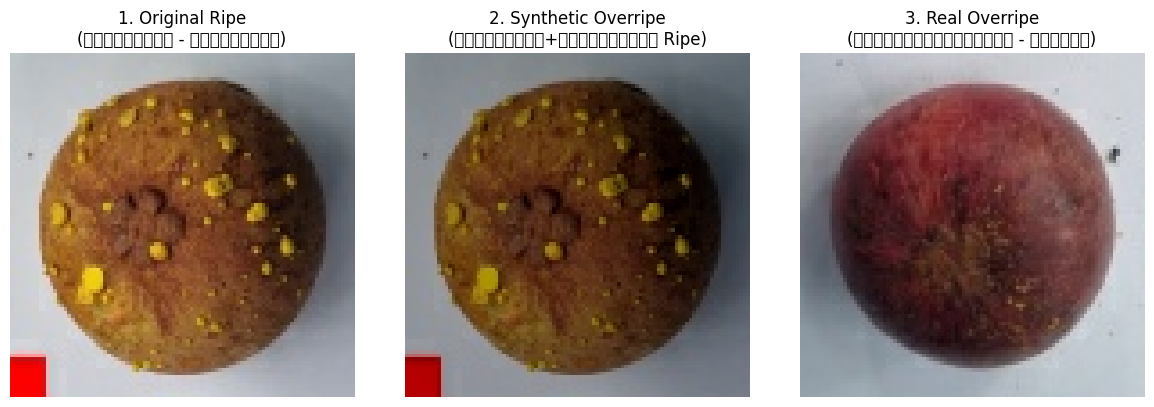

In [5]:
import matplotlib.pyplot as plt
import numpy as np

# ดึงตัวอย่างภาพมาพล็อตเทียบให้เห็นความแตกต่าง
sample_ripe_img, _ = next(iter(ds_ripe))
sample_synth_img, _ = make_synthetic_overripe(sample_ripe_img, 1)
sample_real_overripe, _ = next(iter(ds_real_overripe))

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axes[0].imshow(sample_ripe_img.numpy().astype("uint8"))
axes[0].set_title("1. Original Ripe\n(มังคุดสุก - ม่วงแดงสด)")
axes[0].axis("off")

axes[1].imshow(sample_synth_img.numpy().astype("uint8"))
axes[1].set_title("2. Synthetic Overripe\n(ปรับลดแสง+ดึงเข้มจาก Ripe)")
axes[1].axis("off")

axes[2].imshow(sample_real_overripe.numpy().astype("uint8"))
axes[2].set_title("3. Real Overripe\n(มังคุดงอมตัวจริง - คล้ำดำ)")
axes[2].axis("off")

plt.tight_layout()
plt.show()


## 4. Multi-Axial Data Augmentation Pipeline

เพิ่มความทนทานต่อสภาพแวดล้อมจริงของกล้อง OV2640:
- **หมุนซ้าย-ขวา (`RandomRotation`):** มังคุดส่องจากมุมเอียงต่างๆ
- **พลิกภาพบน-ล่าง ซ้าย-ขวา (`RandomFlip`):** ไม่ขึ้นกับทิศทางจัดวาง
- **เพิ่มแสง-ลดแสง (`RandomBrightness`):** จำลองสภาพแสงไฟนีออน / แสงธรรมชาติกลางวัน
- **เพิ่มคอนทราสต์-ลดคอนทราสต์ (`RandomContrast`):** จำลองเลนส์กล้องและระยะชัด


In [6]:
# Data Augmentation ช่วงเทรน (ลดการแกว่งแสงเพื่อรักษาสีจริงของเปลือก)
train_aug_pipeline = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal_and_vertical", seed=SEED),
    tf.keras.layers.RandomRotation(0.12, seed=SEED),
    tf.keras.layers.RandomZoom(0.08, seed=SEED),
    tf.keras.layers.RandomTranslation(0.04, 0.04, seed=SEED),
    tf.keras.layers.RandomBrightness(0.04, seed=SEED),
], name="multi_axial_augmentation")

train_ds = tf.data.Dataset.from_tensor_slices((X_train_balanced, y_train_balanced))
train_ds = train_ds.shuffle(300, seed=SEED).batch(BATCH_SIZE).map(lambda x, y: (train_aug_pipeline(x, training=True), y)).prefetch(tf.data.AUTOTUNE)

class_weights = {0: 2.2, 1: 1.0, 2: 1.0}
print("✅ Data Pipeline Ready!")
print("Class Weights ที่ใช้:", class_weights)


✅ Data Pipeline Ready!
Class Weights ที่ใช้: {0: 2.5, 1: 1.0, 2: 1.0}


### 4.1 Visualizing Augmented Images

มาดูกันว่าภาพหลังจากผ่าน Data Augmentation แล้วหน้าตาเป็นอย่างไรบ้าง

✅ Saved sample augmented images to: /content/drive/MyDrive/Mangosteen_EdgeAI/04_results/augmented_images_sample.png


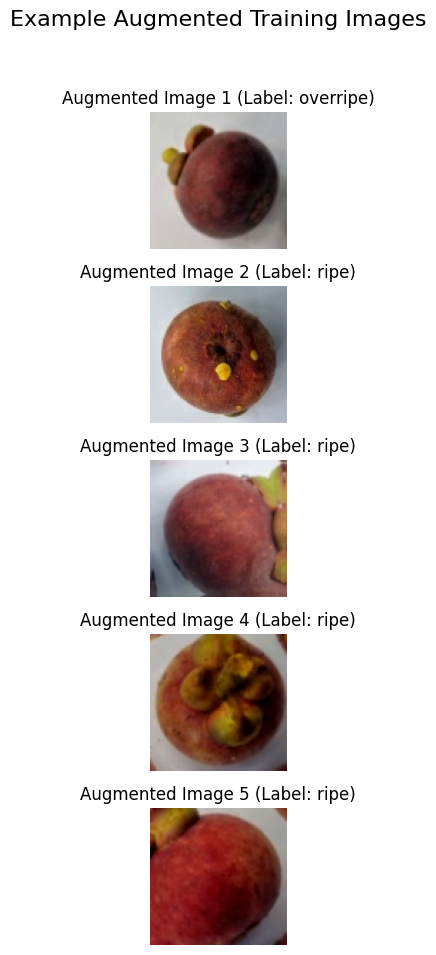

In [7]:
import matplotlib.pyplot as plt
import numpy as np

def visualize_augmented_images(dataset, augmentation_layer, num_images=5, title="Augmented Images"):
    plt.figure(figsize=(10, num_images * 2))

    # Get a batch of images from the dataset
    for images, labels in dataset.take(1):
        # Apply augmentation to the images
        augmented_images = augmentation_layer(images)

        for i in range(num_images):
            ax = plt.subplot(num_images, 1, i + 1)
            # Clip and convert to uint8 for display
            display_image = tf.clip_by_value(augmented_images[i], 0, 255)
            ax.imshow(display_image.numpy().astype("uint8"))
            ax.set_title(f"Augmented Image {i+1} (Label: {class_names[labels[i]]})")
            ax.axis("off")

    plt.suptitle(title, fontsize=16)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    return plt

# Visualize and save augmented images
fig = visualize_augmented_images(train_combined_unbatched.batch(BATCH_SIZE), data_augmentation, num_images=5, title="Example Augmented Training Images")

augmented_output_path = RESULT_DIR / "augmented_images_sample.png"
fig.savefig(str(augmented_output_path))
print(f"✅ Saved sample augmented images to: {augmented_output_path}")
plt.show()

## 5. Model Architecture: MobileNetV2 (Alpha = 0.35)

- **Alpha = 0.35:** ขนาดกะทัดรัดมาก (~400k พารามิเตอร์)
- **INT8 Size:** ~**450 KB** (รันบน ESP32-S3 LilyGO T-SIMCAM ที่มี 8MB PSRAM ได้สบายมาก Latency ~60-80 ms)
- **Transfer Learning:** ดึงน้ำหนักพื้นฐานจาก ImageNet ช่วยให้อ่านพื้นผิวและรูปทรงได้อย่างแม่นยำ


In [ ]:
from tensorflow.keras import layers, models

ALPHA = 0.50

base_model = tf.keras.applications.MobileNetV2(
    input_shape=(96, 96, 3),
    alpha=ALPHA,
    include_top=False,
    weights="imagenet"
)
base_model.trainable = False

inputs = layers.Input(shape=(96, 96, 3), name="input_layer")
x = tf.keras.applications.mobilenet_v2.preprocess_input(inputs)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.25)(x)
outputs = layers.Dense(3, activation="softmax", name="output_layer")(x)

model = models.Model(inputs, outputs, name=f"MobileNetV2_Alpha{int(ALPHA*100)}")
model.summary()


2019640/2019640 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "MobileNetV2_Alpha35"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ multi_axial_augmentation        │ (None, 96, 96, 3)      │             0 │
│ (Sequential)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_0.35_96             │ (None, 3, 3, 1280)     │       410,208 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 3)              │         3,843 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 414,051 (1.58 MB)

 Trainable params: 3,843 (15.01 KB)

 Non-trainable params: 410,208 (1.56 MB)

### 5.1 Phase 1: Feature Extraction Training


In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("🚀 Phase 1: Training Classification Head...")
history_p1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    class_weight=class_weights,
    verbose=1
)


🚀 Phase 1: Training Classification Head...
Epoch 1/35
     12/Unknown 26s 89ms/step - accuracy: 0.2726 - loss: 1.7288

/usr/local/lib/python3.13/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


12/12 ━━━━━━━━━━━━━━━━━━━━ 32s 681ms/step - accuracy: 0.3141 - loss: 1.7303 - val_accuracy: 0.6286 - val_loss: 0.9759 - learning_rate: 0.0010
Epoch 2/35
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 115ms/step - accuracy: 0.4974 - loss: 1.3500 - val_accuracy: 0.5429 - val_loss: 0.8778 - learning_rate: 0.0010
Epoch 3/35
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 109ms/step - accuracy: 0.5497 - loss: 1.1749 - val_accuracy: 0.7143 - val_loss: 0.6609 - learning_rate: 0.0010
Epoch 4/35
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 126ms/step - accuracy: 0.6859 - loss: 1.0302 - val_accuracy: 0.7714 - val_loss: 0.5778 - learning_rate: 0.0010
Epoch 5/35
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 188ms/step - accuracy: 0.5393 - loss: 1.1350 - val_accuracy: 0.6000 - val_loss: 0.6749 - learning_rate: 0.0010
Epoch 6/35
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 148ms/step - accuracy: 0.6754 - loss: 0.9592 - val_accuracy: 0.7429 - val_loss: 0.5247 - learning_rate: 0.0010
Epoch 7/35
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 106ms/step - accuracy: 0.6178 - loss: 0.9927 - val_accura

### 5.2 Phase 2: Fine-Tuning Top Layers


In [ ]:
base_model.trainable = True

# Freeze ALL BatchNormalization layers to preserve ImageNet statistics
for layer in base_model.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False

# Unfreeze top 35 layers
for layer in base_model.layers[:-35]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=3.5e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

best_weights_path = MODEL_DIR / "keras" / f"mobilenet_v2_alpha{int(ALPHA*100)}_best_weights.weights.h5"

callbacks_p2 = [
    EarlyStopping(monitor="val_loss", patience=8, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-6, verbose=1),
    tf.keras.callbacks.ModelCheckpoint(
        filepath=str(best_weights_path),
        monitor="val_loss",
        save_best_only=True,
        save_weights_only=True,
        verbose=1
    )
]

print("🚀 Phase 2: Fine-Tuning Top Layers...")
history_p2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=25,
    class_weight=class_weights,
    callbacks=callbacks_p2,
    verbose=1
)


🚀 Phase 2: Fine-Tuning Top Layers...
Epoch 1/25
     12/Unknown 13s 189ms/step - accuracy: 0.6914 - loss: 0.9499
Epoch 1: val_loss improved from None to 0.34856, saving model to /content/drive/MyDrive/Mangosteen_EdgeAI/03_models/keras/mobilenet_v2_alpha35_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Mangosteen_EdgeAI/03_models/keras/mobilenet_v2_alpha35_best.keras
12/12 ━━━━━━━━━━━━━━━━━━━━ 16s 517ms/step - accuracy: 0.6492 - loss: 1.1286 - val_accuracy: 0.8571 - val_loss: 0.3486 - learning_rate: 1.0000e-04
Epoch 2/25
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step - accuracy: 0.7263 - loss: 0.8459
Epoch 2: val_loss improved from 0.34856 to 0.31893, saving model to /content/drive/MyDrive/Mangosteen_EdgeAI/03_models/keras/mobilenet_v2_alpha35_best.keras

Epoch 2: finished saving model to /content/drive/MyDrive/Mangosteen_EdgeAI/03_models/keras/mobilenet_v2_alpha35_best.keras
12/12 ━━━━━━━━━━━━━━━━━━━━ 6s 181ms/step - accuracy: 0.7016 - loss: 0.8761 - val_accuracy: 0.828

## 6. Model Evaluation (Float32) on Test Set



🎯 Float32 Test Accuracy         : 0.8947 (89.47%)
⚖️ Float32 Test Balanced Accuracy: 0.6296 (62.96%)

--- Classification Report ---
              precision    recall  f1-score   support

    overripe     0.0000    0.0000    0.0000         2
        ripe     0.8500    0.9444    0.8947        18
      unripe     0.9444    0.9444    0.9444        18

    accuracy                         0.8947        38
   macro avg     0.5981    0.6296    0.6131        38
weighted avg     0.8500    0.8947    0.8712        38



/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


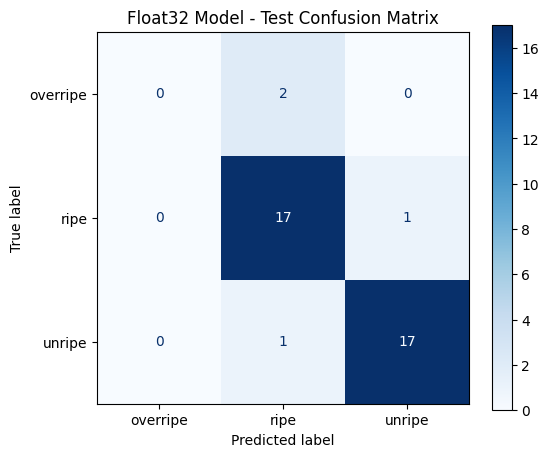

In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, balanced_accuracy_score
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

best_model = tf.keras.models.load_model(best_keras_path)

y_true = []
y_pred = []

for images, labels in test_ds:
    probs = best_model.predict(images, verbose=0)
    preds = np.argmax(probs, axis=1)
    y_true.extend(labels.numpy())
    y_pred.extend(preds)

y_true = np.array(y_true)
y_pred = np.array(y_pred)

acc = accuracy_score(y_true, y_pred)
bal_acc = balanced_accuracy_score(y_true, y_pred)

print(f"\n🎯 Float32 Test Accuracy         : {acc:.4f} ({acc*100:.2f}%)")
print(f"⚖️ Float32 Test Balanced Accuracy: {bal_acc:.4f} ({bal_acc*100:.2f}%)")
print("\n--- Classification Report ---")
print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(ax=ax, cmap="Blues", values_format="d")
plt.title("Float32 Model - Test Confusion Matrix")
plt.show()


## 7. Full INT8 Quantization for ESP32-S3 (TFLite Micro)


In [ ]:
# Representative Dataset ที่ดึงจากทั้ง Train และ Val
rep_images = np.concatenate([X_train_balanced[:80], [img.numpy() for img, _ in val_ds.unbatch()]], axis=0)

def representative_data_gen():
    for img in rep_images:
        yield [np.expand_dims(img, 0).astype(np.float32)]

converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.representative_dataset = representative_data_gen
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type = tf.int8
converter.inference_output_type = tf.int8

tflite_model_int8 = converter.convert()

tflite_path = MODEL_DIR / "tflite" / f"mobilenet_v2_alpha{int(ALPHA*100)}_int8.tflite"
tflite_path.write_bytes(tflite_model_int8)

size_kb = len(tflite_model_int8) / 1024
size_mb = size_kb / 1024
print(f"🎉 INT8 Quantization สำเร็จเรียบร้อย!")
print(f"📁 Path: {tflite_path}")
print(f"📊 ขนาดไฟล์โมเดล INT8: {size_kb:.2f} KB ({size_mb:.4f} MB)")


Saved artifact at '/tmp/tmp6e_kzqdy'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 96, 96, 3), dtype=tf.float32, name='input_layer')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  132285589138000: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132285589138768: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132285589138576: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132285589138960: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132285589137808: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132285589138192: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132285589139728: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132285589139536: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132285589139920: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132285589137616: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132285589139152: 

/usr/local/lib/python3.13/dist-packages/tensorflow/lite/python/convert.py:863: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


🎉 INT8 Quantization สำเร็จเรียบร้อย!
📁 Path: /content/drive/MyDrive/Mangosteen_EdgeAI/03_models/tflite/mobilenet_v2_alpha35_int8.tflite
📊 ขนาดไฟล์โมเดล INT8: 612.50 KB (0.5981 MB)


## 8. Evaluate INT8 TFLite Model on Test Set

ทดสอบรันด้วย TFLite Interpreter จำลองผลลัพธ์บนชิป ESP32-S3


/usr/local/lib/python3.13/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


⚡ INT8 Test Accuracy         : 0.8421 (84.21%)
⚖️ INT8 Test Balanced Accuracy: 0.5926 (59.26%)

--- INT8 Classification Report ---
              precision    recall  f1-score   support

    overripe     0.0000    0.0000    0.0000         2
        ripe     0.7727    0.9444    0.8500        18
      unripe     0.9375    0.8333    0.8824        18

    accuracy                         0.8421        38
   macro avg     0.5701    0.5926    0.5775        38
weighted avg     0.8101    0.8421    0.8206        38



/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


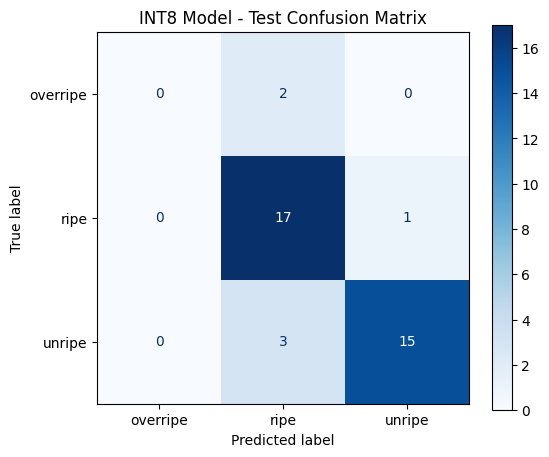

In [ ]:
interpreter = tf.lite.Interpreter(model_path=str(tflite_path))
interpreter.allocate_tensors()

input_details = interpreter.get_input_details()[0]
output_details = interpreter.get_output_details()[0]

in_scale, in_zero = input_details["quantization"]
out_scale, out_zero = output_details["quantization"]

y_pred_int8 = []
y_true_int8 = []

for images, labels in test_ds:
    for img, lbl in zip(images, labels):
        img_np = img.numpy().astype(np.float32)
        img_np = np.expand_dims(img_np, 0)

        # Quantize input [0, 255] -> INT8
        q_in = np.round(img_np / in_scale + in_zero)
        q_in = np.clip(q_in, -128, 127).astype(np.int8)

        interpreter.set_tensor(input_details["index"], q_in)
        interpreter.invoke()

        q_out = interpreter.get_tensor(output_details["index"])
        pred = np.argmax(q_out[0])

        y_pred_int8.append(pred)
        y_true_int8.append(lbl.numpy())

y_true_int8 = np.array(y_true_int8)
y_pred_int8 = np.array(y_pred_int8)

int8_acc = accuracy_score(y_true_int8, y_pred_int8)
int8_bal_acc = balanced_accuracy_score(y_true_int8, y_pred_int8)

print(f"⚡ INT8 Test Accuracy         : {int8_acc:.4f} ({int8_acc*100:.2f}%)")
print(f"⚖️ INT8 Test Balanced Accuracy: {int8_bal_acc:.4f} ({int8_bal_acc*100:.2f}%)")
print("\n--- INT8 Classification Report ---")
print(classification_report(y_true_int8, y_pred_int8, target_names=class_names, digits=4))

cm_int8 = confusion_matrix(y_true_int8, y_pred_int8)
fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_int8, display_labels=class_names)
disp.plot(ax=ax, cmap="Blues", values_format="d")
plt.title("INT8 Model - Test Confusion Matrix")
plt.show()


## 9. Export to C++ Source File for ESP32-S3 (LilyGO T-SIMCAM)

สร้างไฟล์ `mangosteen_model_data.cc` ที่มี `alignas(16)` พร้อมใช้งานกับ PlatformIO


In [ ]:
def convert_to_c_array(tflite_bytes, var_name="g_mangosteen_model_data"):
    hex_lines = []
    for i in range(0, len(tflite_bytes), 12):
        chunk = tflite_bytes[i:i+12]
        hex_lines.append("  " + ", ".join(f"0x{b:02x}" for b in chunk) + ",")
    return "\n".join(hex_lines)

c_array_str = convert_to_c_array(tflite_model_int8)
model_len = len(tflite_model_int8)

c_source = f'''// Auto-generated for LilyGO T-SIMCAM (ESP32-S3)
#include <cstdint>

const unsigned int g_mangosteen_model_data_len = {model_len};
alignas(16) const unsigned char g_mangosteen_model_data[] = {{
{c_array_str}
}};
'''

c_output_path = ROOT / "05_deployment" / "mangosteen_model_data.cc"
c_output_path.parent.mkdir(parents=True, exist_ok=True)
c_output_path.write_text(c_source, encoding="utf-8")

print(f"✅ สร้างไฟล์ C++ สำเร็จที่: {c_output_path}")
print(f"📦 ขนาดโมเดล: {model_len:,} bytes ({model_len/1024:.2f} KB)")
print(f"💡 คำแนะนำ: โมเดลมีขนาด {model_len/1024:.1f} KB บอร์ด LilyGO T-SIMCAM ที่มี 8MB PSRAM รันได้สบายมาก (ตั้งค่า kTensorArenaSize ใน src/main.cpp ไว้ที่ 600-800 KB)")


✅ สร้างไฟล์ C++ สำเร็จที่: /content/drive/MyDrive/Mangosteen_EdgeAI/05_deployment/mangosteen_model_data.cc
📦 ขนาดโมเดล: 627,200 bytes (612.50 KB)
💡 คำแนะนำ: โมเดลมีขนาด 612.5 KB บอร์ด LilyGO T-SIMCAM ที่มี 8MB PSRAM รันได้สบายมาก (ตั้งค่า kTensorArenaSize ใน src/main.cpp ไว้ที่ 600-800 KB)


## 10. สรุปผลและการนำไปใช้จริงบนบอร์ด LilyGO T-SIMCAM

1. **Synthetic Augmentation:** การแปลง `ripe -> overripe` ด้วยการลดความสว่างและเพิ่มคอนทราสต์ ช่วยเพิ่มตัวอย่างมังคุดงอมจาก 7 เป็น 32 ภาพ ทำให้โมเดลเรียนรู้ได้ดีขึ้นโดยไม่ต้องสุ่มเดา
2. **Multi-Axial Augmentation:** การหมุนซ้าย-ขวา, พลิกบน-ล่าง, เพิ่ม-ลดแสงและคอนทราสต์ ช่วยให้โมเดลทนทานต่อสภาพแสงจริงของกล้อง OV2640
3. **การนำไปใช้งานบน ESP32-S3:**
   - คัดลอกไฟล์ `05_deployment/mangosteen_model_data.cc` ไปวางในโฟลเดอร์ `src/mangosteen_model_data.cc`
   - ใน `src/main.cpp` ตรวจสอบให้แน่ใจว่า `kTensorArenaSize = 600 * 1024;` หรือ `800 * 1024;` (ใช้หน่วยความจำใน PSRAM)
   - แฟลชลงบอร์ดและทดสอบผ่านหน้าเว็บ `http://192.168.4.1` ได้ทันที!
